In [1]:
import pyrealsense2 as rs
import numpy as np
import cv2
import os
import time


In [2]:
context = rs.context()
devices = list(context.query_devices())
devices

[<pyrealsense2.device: D435 (S/N: 250122077547  FW: 5.13.0.55  on USB)>,
 <pyrealsense2.device: D435 (S/N: 250122072156  FW: 5.13.0.55  on USB)>]

In [3]:
pipeline = rs.pipeline()
config = rs.config()


In [ ]:
config.enable_device("250122077547")  # left
config.enable_device("250122072156")  # right
config.enable_stream(rs.stream.color, 1280, 720, rs.format.bgr8, 30)
config.enable_stream(rs.stream.depth, 1280, 720, rs.format.z16, 30)
profile = pipeline.start(config)

In [5]:
color_stream = profile.get_stream(rs.stream.color)
depth_stream = profile.get_stream(rs.stream.depth)
color_stream_profile = color_stream.as_video_stream_profile()
depth_stream_profile = depth_stream.as_video_stream_profile()
color_stream_intrinsics = color_stream_profile.get_intrinsics()
color_stream_extrinsics = color_stream_profile.get_extrinsics_to(color_stream_profile)
depth_stream_intrinsics = depth_stream_profile.get_intrinsics()
depth_stream_extrinsics = depth_stream_profile.get_extrinsics_to(color_stream_profile)

In [6]:
def intrinsics_to_matrix(intrinsics):
    K = np.array([[intrinsics.fx, 0, intrinsics.ppx],
                  [0, intrinsics.fy, intrinsics.ppy],
                  [0, 0, 1]])
    return K
def extrinsics_to_matrix(extrinsics):
    R = np.array(extrinsics.rotation).reshape(3, 3)
    T = np.array(extrinsics.translation).reshape(3, 1)
    RT = np.hstack((R, T))
    RT = np.vstack((RT, np.array([0, 0, 0, 1])))
    return RT
color_K = intrinsics_to_matrix(color_stream_intrinsics)
depth_K = intrinsics_to_matrix(depth_stream_intrinsics)
color_RT = extrinsics_to_matrix(color_stream_extrinsics)
depth_RT = extrinsics_to_matrix(depth_stream_extrinsics)
color_K, depth_K, color_RT, depth_RT

(array([[909.90081787,   0.        , 645.4564209 ],
        [  0.        , 909.75537109, 369.97555542],
        [  0.        ,   0.        ,   1.        ]]),
 array([[643.2935791 ,   0.        , 643.69537354],
        [  0.        , 643.2935791 , 354.92712402],
        [  0.        ,   0.        ,   1.        ]]),
 array([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]]),
 array([[ 9.99951303e-01, -9.75478347e-03,  1.47817028e-03,
          1.47890728e-02],
        [ 9.74856131e-03,  9.99943852e-01,  4.16003074e-03,
          5.17218868e-05],
        [-1.51866744e-03, -4.14541829e-03,  9.99990225e-01,
          2.74955790e-04],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          1.00000000e+00]]))

In [7]:
device = profile.get_device()
depth_sensor = device.first_depth_sensor()
depth_sensor.get_depth_scale()

0.0010000000474974513

In [ ]:
import json
auto_calibrated_device = device.as_auto_calibrated_device()
json_content = json.dumps({
    "calib type": 0,
    "speed": 2,
    "scan parameter": 0,
    "white wall mode": 0
})
timeout_ms = 10000
auto_calibrated_device.run_on_chip_calibration(json_content, timeout_ms)

RuntimeError: hwmon command 0x80( 8 2 0 8 ) failed (response -7= HW not ready)

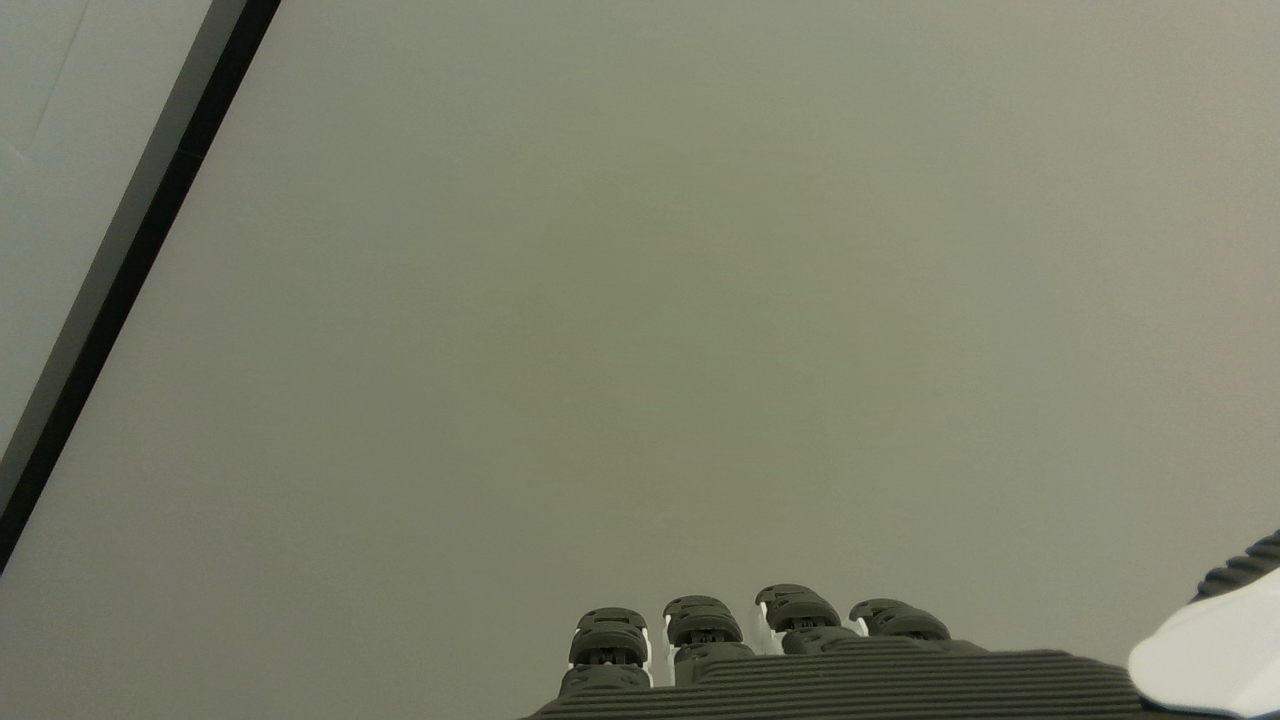

In [8]:
import PIL.Image
import matplotlib.pyplot as plt
frame = pipeline.wait_for_frames()
color_frame = frame.get_color_frame()
color_image = np.asanyarray(color_frame.get_data())
PIL.Image.fromarray(color_image)
# depth_frame = frame.get_depth_frame()
# depth_image = np.asanyarray(depth_frame.get_data())
# # PIL.Image.fromarray(depth_image)
# plt.imshow(depth_image)
# plt.colorbar()

np.False_

In [31]:
stereo = profile.get_device().sensors[0]
# get depth scale
depth_scale = stereo.get_depth_scale()

AttributeError: 'pyrealsense2.pyrealsense2.sensor' object has no attribute 'get_depth_scale'

In [20]:
pipeline.wait_for_frames()

<pyrealsense2.frameset  Z16 #362 @1760925508319.617676  BGR8 #394 @1760925508319.641602>

In [13]:
451 / 2.5, 722 / 4.0

(180.4, 180.5)

In [10]:
1123 / 29.7, 793 / 21.0

(37.81144781144781, 37.76190476190476)

In [14]:
151 / 1.7, 90 / 1.0

(88.82352941176471, 90.0)